**Hallazgos de la revisión de los adjuntos:**

- `Entrega3_Eq1.pdf`, sección 7, define HAC como Newey–West con 24 rezagos.
- `3_features.ipynb` une por intersección antes de aplicar ventanas y rezagos por fila.
  Con horas faltantes, ocho filas no equivalen a ocho horas.
- `script_final_tareas.py` aplica HAC simple a estaciones apiladas. Esa llamada presupone
  una sola serie regularmente espaciada. Aquí conservamos el tiempo real y calculamos
  HAC temporal por estación y una covarianza del panel que admite dependencia espacial.
- El Parquet predictivo adjunto tiene 413,291 filas, no se debe reutilizar 536,075 como su N.
- Los dos archivos de PM2.5 adjuntos son iguales. Persisten dos códigos 999/997 en los
  archivos principales, uno en PM10 y otro en PM2.5. Se registran antes de anularlos.

**Tres conceptos distintos:** unir datos conserva una fila por estación y hora,
promediar estaciones cambia la unidad de observación, HAC corrige errores estándar de
coeficientes. HAC no modifica las predicciones de OLS, no reduce su RMSE y no demuestra
causalidad. Una dispersión alta motiva mejores modelos; no significa que el proyecto sea inviable.

## Resultados de control con los archivos adjuntos


| Decisión o resultado | Valor |
|---|---|
| Excluir del modelo por menor cobertura conjunta de entrenamiento | NE3, NO3, NO |
| Conservar | CE, NE, NE2, NO2, NTE, NTE2, SE, SE2, SE3, SO, SO2, SUR |
| Observaciones del modelo en 2020–2024 | 326,170 |
| Observaciones del modelo en 2025 | 63,907 |
| RMSE de prueba, siete predictores | 13.5101 ppb |
| RMSE de prueba, siete predictores + estación | 13.2322 ppb |
| DMA de O3 frente al promedio de las otras estaciones | Entre 4.59 y 8.29 ppb, según estación |
| LSTM-NARX | Código preparado; entrenamiento no ejecutado |

La covarianza implementada se cotejó numéricamente con las funciones de Statsmodels
para HAC de una serie regular y Driscoll–Kraay de un panel sin huecos. También se
verificaron invariancia al orden de las filas y rezagos ante horas faltantes.
La autorización de Drive y la descarga interactiva no se probaron dentro de Colab.

**Limitaciones que sí afectan las conclusiones:** NE y NE2 tienen muy poca cobertura
conjunta en 2025. Los resultados representan observaciones disponibles y no garantizan
cobertura de toda la estación o temporada. El panel original ya había pasado por filtros
que no pueden revertirse a partir de los Parquet. Los SE robustos no solucionan sesgos
por ausencia de datos ni especificación incorrecta del modelo.


## 1. Preparar Colab

La parte principal usa CPU. Para la LSTM no está entrenada todavía.

In [9]:
%pip -q install pandas numpy pyarrow scipy statsmodels matplotlib

In [10]:
from pathlib import Path
import re, json, hashlib, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm
from IPython.display import display

USAR_DRIVE = True
if USAR_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = Path('/content/drive/MyDrive/Multivariados_Mikey')
else:
    # Alternativa: subir los Parquet con el panel de archivos de Colab.
    BASE = Path('/content/Multivariados_Mikey')
DATOS = BASE / 'datos'
SALIDA = BASE / 'resultados'
SALIDA.mkdir(parents=True, exist_ok=True)

INICIO = pd.Timestamp('2020-01-01 00:00')
FIN = pd.Timestamp('2025-12-31 23:00')
CORTE = pd.Timestamp('2025-01-01')
ESTACIONES = ['CE','NE','NE2','NE3','NO','NO2','NO3','NTE','NTE2',
              'SE','SE2','SE3','SO','SO2','SUR']
CORE = ['O3','NOX','SR','TOUT','WSR','WDR','PM10','PM2.5']
TODAS = ['CO','NO','NO2','NOX','O3','PM10','PM2.5','PRS','RAINF',
         'RH','SO2','SR','TOUT','WSR','WDR']
pd.set_option('display.max_columns', 25)
plt.rcParams.update({'figure.figsize':(11,5), 'font.size':10})
print('Datos:', DATOS)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datos: /content/drive/MyDrive/Multivariados_Mikey/datos


## 2. Leer, auditar y unir las variables

La llave es **Estacion + Date**. La unión externa conserva mediciones aunque falten otras
variables. Luego completamos el calendario ya que los huecos quedan como `NaN`, nunca como cero.
No eliminamos atípicos por alejarse de la media. Conservamos la limpieza de rangos del
equipo y anulamos explícitamente los códigos 997/999 documentados en la entrega.
La selección de banderas y los rangos del pipeline original siguen siendo una limitación
heredada: no recuperamos mediciones ya descartadas por ese pipeline.

Se exige unicidad de la llave. Los duplicados conflictivos detienen la ejecución para
evitar promediarlos silenciosamente. Las fechas se conservan tal como las entrega SIMA,
sin inventar conversiones de zona horaria.

In [11]:
def candidatos(nombre):
    # Acepta también prefijos de descarga como 12-O3_clean.parquet.
    return sorted(p for p in DATOS.rglob('*.parquet')
                  if re.sub(r'^\d+-', '', p.name) == nombre)

def leer_variable(p, var):
    d = pd.read_parquet(p)
    if var == 'PM2.5' and 'PM25' in d:
        d = d.rename(columns={'PM25':'PM2.5'})
    requeridas = ['Estacion','Date',var]
    if not set(requeridas).issubset(d.columns):
        raise ValueError(f'{p.name}: faltan columnas {requeridas}')
    d = d[requeridas].copy()
    d['Estacion'] = d.Estacion.astype(str).str.strip().str.upper()
    d['Date'] = pd.to_datetime(d.Date, errors='raise')
    if d.Date.isna().any() or not d.Date.eq(d.Date.dt.floor('h')).all():
        raise ValueError(f'{p.name}: fechas vacías o no horarias')
    if set(d.Estacion)-set(ESTACIONES):
        raise ValueError(f'{p.name}: estaciones desconocidas')
    d[var] = pd.to_numeric(d[var], errors='raise').astype(float)
    if d.duplicated(['Estacion','Date']).any():
        raise ValueError(f'{p.name}: llave duplicada; revisar antes de unir')
    return d.set_index(['Estacion','Date']).sort_index()

tablas, auditoria = [], []
for var in TODAS:
    rutas = candidatos(f'{var}_clean.parquet')
    if var == 'PM2.5': rutas += candidatos('PM25_clean.parquet')
    if not rutas:
        if var in CORE: raise FileNotFoundError(f'Falta {var}_clean.parquet en {DATOS}')
        print('Variable adicional no cargada:', var)
        continue
    d = leer_variable(rutas[0], var)
    for otra in rutas[1:]:
        if not d.equals(leer_variable(otra,var)):
            raise ValueError(f'Copias distintas para {var}: {rutas}')
    bandera = d[var].isin([997,999])
    auditoria.append({'variable':var,'archivo':rutas[0].name,'filas':len(d),
                     'codigos_997_999':int(bandera.sum()),
                     'copias_equivalentes':len(rutas)})
    d.loc[bandera,var] = np.nan
    d[var] = d[var].replace([np.inf,-np.inf],np.nan)
    tablas.append(d)

unido = pd.concat(tablas,axis=1).sort_index()
fechas = pd.date_range(INICIO, FIN, freq='h')
indice = pd.MultiIndex.from_product([ESTACIONES, fechas],names=['Estacion','Date'])
panel = unido.reindex(indice).sort_index()
del unido, tablas
assert panel.index.is_unique
assert len(panel) == len(ESTACIONES)*len(fechas)
auditoria = pd.DataFrame(auditoria)
display(auditoria)
print('Panel completo:', panel.shape, '| Una fila por estación y hora.')
auditoria.to_csv(SALIDA/'01_auditoria_archivos.csv',index=False)

,variable,archivo,filas,codigos_997_999,copias_equivalentes
0,CO,CO_clean.parquet,654137,0,1
1,NO,NO_clean.parquet,627938,0,1
2,NO2,NO2_clean.parquet,623499,0,1
3,NOX,NOX_clean.parquet,627434,0,1
4,O3,O3_clean.parquet,643436,0,1
5,PM10,PM10_clean.parquet,719672,1,1
6,PM2.5,PM2.5_clean.parquet,564250,1,2
7,PRS,PRS_clean.parquet,708099,0,1
8,RAINF,RAINF_clean.parquet,718843,0,1
9,RH,RH_clean.parquet,668445,0,1


Panel completo: (789120, 15) | Una fila por estación y hora.


## 3. Justificar cuáles tres estaciones quitar

Ordenamos por porcentaje de horas con las ocho variables observadas simultáneamente
en 2020–2024, de menor a mayor. La decisión usa entrenamiento; mostramos 2025 después
para describir cobertura, sin elegir estaciones por su resultado de prueba.

Con estos adjuntos, las candidatas a excluir son **NE3, NO3 y NO**. Si cambian los datos,
el ranking vuelve a calcularse. Estación NO y variable contaminante NO son campos distintos.
No eliminamos estas estaciones del archivo original ni de los conteos de ozono del bloque 14.

,n_completas_train,pct_8_train,pct_8_test,pct_O3_train,pct_PM2.5_train,pct_NOX_train,racha_sin_8_train_h,decision
Estacion,,,,,,,,
NE3,0,0.00,20.86,76.23,0.00,75.27,43848,Excluir del modelo
NO3,2297,5.24,12.09,37.63,5.32,35.66,37094,Excluir del modelo
NO,15580,35.53,3.36,71.57,64.42,73.93,10320,Excluir del modelo
NTE,22808,52.02,66.46,73.15,83.68,71.12,10914,Conservar
NE2,23345,53.24,3.38,74.80,79.81,76.03,9880,Conservar
SUR,24111,54.99,64.85,75.43,68.16,77.00,10321,Conservar
NO2,24366,55.57,47.73,92.96,85.40,94.69,1745,Conservar
SE,25241,57.56,83.00,95.74,86.80,74.44,10329,Conservar
NE,25967,59.22,6.76,74.28,92.72,75.92,10070,Conservar


QUITAR: ['NE3', 'NO3', 'NO'] 
USAR: ['CE', 'NE', 'NE2', 'NO2', 'NTE', 'NTE2', 'SE', 'SE2', 'SE3', 'SO', 'SO2', 'SUR']


year,2020,2021,2022,2023,2024,2025
Estacion,,,,,,
CE,59.5,68.3,87.9,85.3,77.5,79.9
NE,0.0,72.1,91.5,84.3,48.5,6.8
NE2,1.4,67.2,64.0,79.6,54.1,3.4
NE3,0.0,0.0,0.0,0.0,0.0,20.9
NO,0.0,56.3,65.0,42.4,14.1,3.4
NO2,46.7,70.2,72.2,53.7,35.0,47.7
NO3,0.0,0.0,0.0,0.0,26.1,12.1
NTE,0.0,43.8,73.7,69.4,73.3,66.5
NTE2,2.8,71.9,91.8,85.9,85.4,85.8


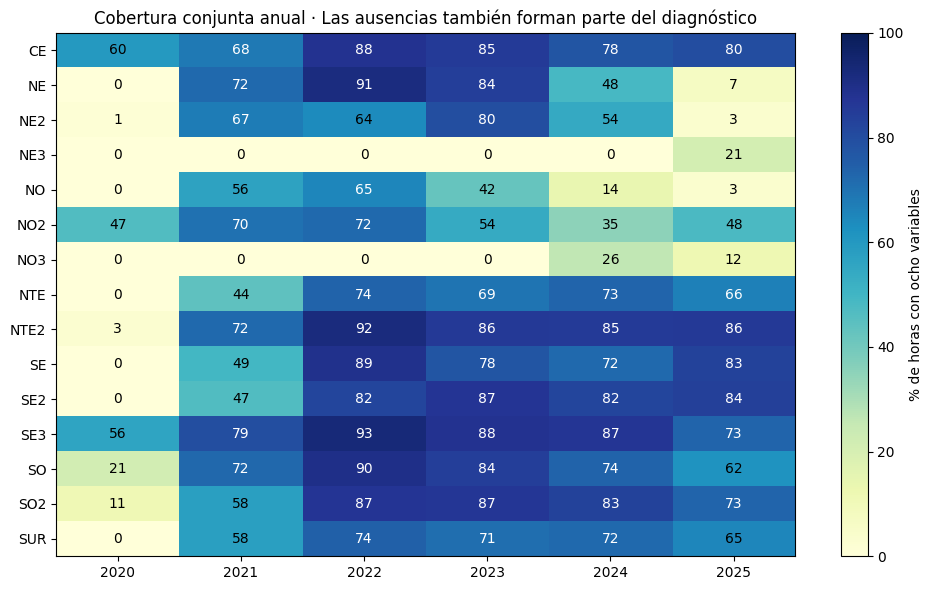

In [12]:
es_train = panel.index.get_level_values('Date') < CORTE
completo = panel[CORE].notna().all(axis=1)
calidad = pd.DataFrame(index=pd.Index(ESTACIONES,name='Estacion'))
calidad['n_completas_train'] = completo[es_train].groupby(level=0).sum()
calidad['pct_8_train'] = 100*completo[es_train].groupby(level=0).mean()
calidad['pct_8_test'] = 100*completo[~es_train].groupby(level=0).mean()
for var in ['O3','PM2.5','NOX']:
    calidad[f'pct_{var}_train'] = 100*panel.loc[es_train,var].notna().groupby(level=0).mean()

def racha_max(mask):
    a=np.r_[False,np.asarray(mask,dtype=bool),False].astype(int)
    return int((np.flatnonzero(np.diff(a)==-1)-np.flatnonzero(np.diff(a)==1)).max(initial=0))

calidad['racha_sin_8_train_h'] = (~completo[es_train]).groupby(level=0).agg(racha_max)
calidad = calidad.sort_values(['pct_8_train','Estacion'])
QUITAR = calidad.index[:3].tolist()
USAR = sorted(set(ESTACIONES)-set(QUITAR))
calidad['decision'] = np.where(calidad.index.isin(USAR),'Conservar','Excluir del modelo')
display(calidad.round(2))
print('QUITAR:',QUITAR,'\nUSAR:',USAR)
assert len(USAR)==12
calidad.to_csv(SALIDA/'02_seleccion_estaciones.csv')

# Cobertura anual: permite detectar si una estación sólo aporta en ciertas épocas.
anual = panel[CORE].notna().all(axis=1).rename('completa').reset_index()
anual['year'] = anual.Date.dt.year
cobertura_anual = 100*anual.groupby(['Estacion','year']).completa.mean().unstack()
display(cobertura_anual.round(1))
cobertura_anual.to_csv(SALIDA/'03_cobertura_anual.csv')
fig,ax=plt.subplots(figsize=(10,6))
im=ax.imshow(cobertura_anual,vmin=0,vmax=100,cmap='YlGnBu',aspect='auto')
ax.set_xticks(range(len(cobertura_anual.columns)),cobertura_anual.columns)
ax.set_yticks(range(len(cobertura_anual)),cobertura_anual.index)
for i in range(len(cobertura_anual)):
    for j in range(len(cobertura_anual.columns)):
        val=cobertura_anual.iloc[i,j]
        ax.text(j,i,f'{val:.0f}',ha='center',va='center',color='white' if val>65 else 'black')
fig.colorbar(im,ax=ax,label='% de horas con ocho variables')
ax.set_title('Cobertura conjunta anual · Las ausencias también forman parte del diagnóstico')
fig.tight_layout(); fig.savefig(SALIDA/'cobertura_anual.png',dpi=150); plt.show()

## 4. Qué tanto se alejan las observaciones de su promedio

Para cada estación y variable calculamos la desviación estándar, los percentiles y:

$
\mathrm{DMA}=\frac1n\sum_i|x_i-\bar x|,\qquad
\mathrm{RMSE}_{\bar x}=\sqrt{\frac1n\sum_i(x_i-\bar x)^2}.
$

**Se utilizan todos los valores individuales disponibles en entrenamiento**, no una
tabla de medias como si fueran las observaciones originales. El percentil 95 de
\(|x_i-\bar x|\) describe la distancia que no supera el 95 % de los datos.

El CV se muestra sólo para concentraciones con media positiva; no se usa para temperatura
en Celsius, viento vectorial o radiación nocturna. No hay un corte universal de CV que
invalide el modelado. Para O3 también medimos distancias de 10 y 20 ppb, referencias
descriptivas editables, **no límites oficiales de aceptación**.

,Estacion,Variable,n,media,mediana,DE,CV_pct,p05,p95,DMA,RMSE_media,p95_distancia,pct_dist_mayor10,pct_dist_mayor20
0,CE,O3,40284,29.03,25.0,20.26,69.79,4.0,68.0,15.88,20.26,38.97,64.36,31.32
6,NE,O3,32571,27.42,24.0,16.90,61.62,5.0,59.0,13.22,16.90,31.58,55.68,21.57
12,NE2,O3,32800,21.97,19.0,14.26,64.92,6.0,49.0,11.10,14.26,27.03,48.03,9.99
18,NO2,O3,40759,25.51,20.0,20.02,78.47,5.0,66.0,15.38,20.02,40.49,63.51,23.31
24,NTE,O3,32075,26.11,22.0,18.82,72.06,4.0,62.0,14.86,18.82,35.89,62.31,28.31
30,NTE2,O3,33828,24.61,20.0,17.51,71.16,5.0,58.0,13.53,17.51,33.39,58.06,17.42
36,SE,O3,41979,27.32,24.0,18.36,67.23,4.0,61.0,14.52,18.36,33.68,60.23,27.45
42,SE2,O3,29934,28.35,25.0,16.58,58.50,8.0,59.0,12.91,16.58,30.65,55.42,18.13
48,SE3,O3,40122,24.65,22.0,15.24,61.83,4.0,52.0,11.69,15.24,27.35,48.76,15.20
54,SO,O3,39147,27.70,23.0,21.78,78.63,3.0,70.0,16.92,21.78,42.30,65.85,33.94


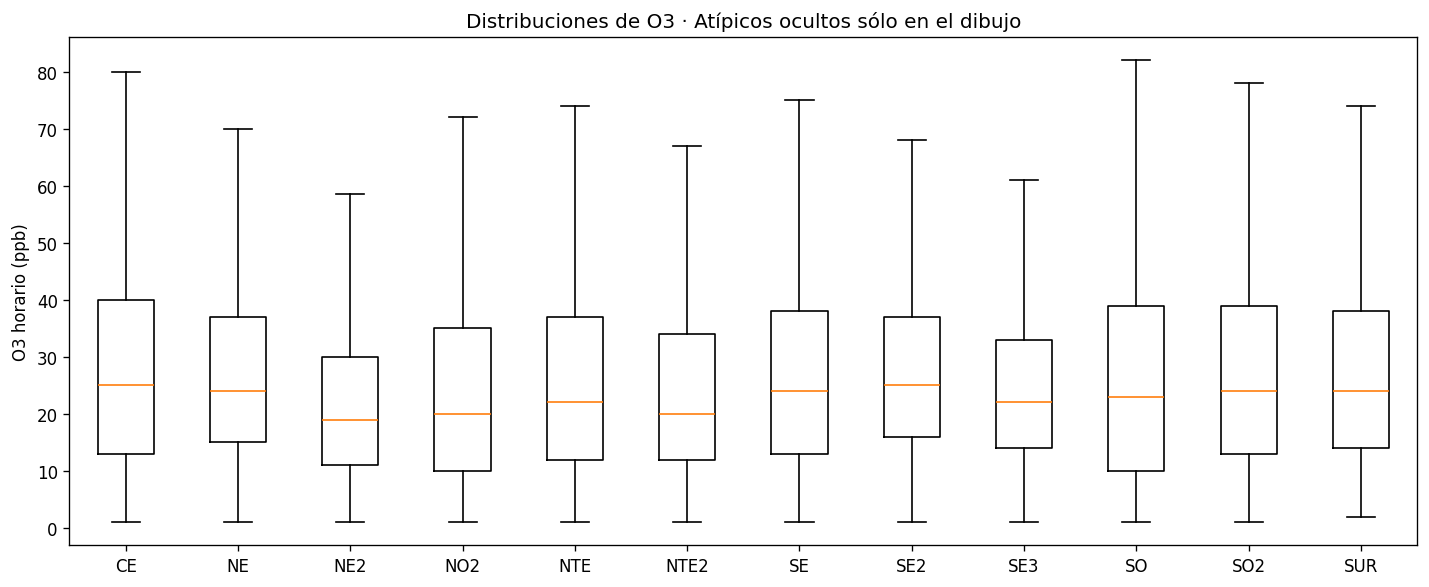

In [ ]:
p12=panel.loc[USAR].copy()
ent=p12.loc[p12.index.get_level_values('Date')<CORTE]
filas=[]
for est,g in ent.groupby(level='Estacion'):
    for var in ['O3','PM2.5','PM10','NOX','SR','TOUT']:
        x=g[var].dropna().to_numpy()
        if len(x)==0: continue
        media=x.mean(); desv=np.abs(x-media)
        filas.append(dict(Estacion=est,Variable=var,n=len(x),media=media,
          mediana=np.median(x),DE=np.std(x,ddof=1),
          CV_pct=100*np.std(x,ddof=1)/media if var in ['O3','PM2.5','PM10','NOX'] and media>0 else np.nan,
          p05=np.quantile(x,.05),p95=np.quantile(x,.95),
          DMA=desv.mean(),RMSE_media=np.sqrt(np.mean((x-media)**2)),
          p95_distancia=np.quantile(desv,.95),
          pct_dist_mayor10=100*(desv>10).mean() if var=='O3' else np.nan,
          pct_dist_mayor20=100*(desv>20).mean() if var=='O3' else np.nan))
dispersion=pd.DataFrame(filas)
display(dispersion.query("Variable=='O3'").round(2))
dispersion.to_csv(SALIDA/'04_dispersion_todos_los_valores.csv',index=False)

ozono_est=[ent.xs(e).O3.dropna().to_numpy() for e in USAR]
fig,ax=plt.subplots(figsize=(12,5))
ax.boxplot(ozono_est,showfliers=False)
ax.set_xticks(range(1,len(USAR)+1),USAR)
ax.set_ylabel('O3 horario (ppb)'); ax.set_title('Distribuciones de O3 · Atípicos ocultos sólo en el dibujo')
fig.tight_layout();fig.savefig(SALIDA/'dispersion_O3.png',dpi=150);plt.show()

## 5. ¿Un promedio espacial representa a cada estación?

Ahora comparamos cada medición de O3 con **el promedio de las otras estaciones a esa
misma hora**. Excluir la estación del promedio evita acercarla artificialmente a sí misma.
Se requieren al menos seis estaciones adicionales con dato; revisa el número de
comparaciones. Los grupos y promedios cambian de composición cuando faltan sensores.
Por eso añadimos una sensibilidad con horas en que están las doce estaciones.

Un sesgo positivo indica que la estación suele estar por encima de las otras. Una DMA
alta o muchas diferencias mayores de 10 ppb indican que el promedio espacial pierde
detalle local. Conservaremos las filas individuales y una variable de estación en la regresión.

In [ ]:
wide=ent.O3.unstack('Estacion').reindex(columns=USAR)
n=wide.notna().sum(axis=1)
otra_media=wide.rsub(wide.sum(axis=1),axis=0).div(n-1,axis=0)
diferencias=(wide-otra_media).where(n>=7)
comparacion=pd.DataFrame({
    'n_comparaciones':diferencias.count(),
    'sesgo_ppb':diferencias.mean(),
    'DMA_ppb':diferencias.abs().mean(),
    'RMSE_ppb':np.sqrt(diferencias.pow(2).mean()),
    'p95_abs_ppb':diferencias.abs().quantile(.95),
    'pct_abs_mayor10':100*diferencias.abs().gt(10).sum()/diferencias.count(),
    'DMA_12_presentes':diferencias.loc[n==12].abs().mean(),
    'n_12_presentes':diferencias.loc[n==12].count()})
display(comparacion.round(2))
comparacion.to_csv(SALIDA/'05_representatividad_promedio_espacial.csv')

,n_comparaciones,sesgo_ppb,DMA_ppb,RMSE_ppb,p95_abs_ppb,pct_abs_mayor10,DMA_12_presentes,n_12_presentes
Estacion,,,,,,,,
CE,33344,1.74,5.45,7.73,16.00,14.11,5.42,22232
NE,32522,0.60,4.95,7.53,14.40,10.45,4.70,22232
NE2,32582,-5.13,8.29,11.75,24.91,28.86,8.52,22232
NO2,33696,-0.62,7.71,11.46,25.09,25.14,7.32,22232
NTE,32045,-0.93,4.66,6.93,13.73,10.32,4.71,22232
NTE2,33134,-2.10,4.59,6.70,13.11,9.78,4.48,22232
SE,33889,1.30,5.10,7.01,14.18,12.22,5.14,22232
SE2,29830,2.15,6.60,8.99,17.00,19.36,6.69,22232
SE3,33753,-1.72,6.85,10.26,21.64,20.21,7.01,22232


## 6. Reconstruir promedios móviles y rezagos en horas reales

Cada estación tiene ahora un registro por hora. Las ventanas atraviesan `NaN` sin comprimir
el tiempo. O3_8h usa una ventana retrospectiva de ocho horas y exige al menos seis
mediciones; también conservamos el conteo de mediciones de la ventana.

El promedio ponderado PM de 12 h conserva la fórmula del equipo: peso mínimo 0.5 y
al menos dos observaciones en las tres horas más recientes. Los pesos respetan la edad
real de cada dato. Es una transformación para modelado, sin certificación normativa.

Replicamos los **siete predictores de la entrega** (rezagos 8, 8, 17, 2, 1 y viento actual).
Este modelo explica/estima O3_8h de la hora actual: usar viento actual no equivale a un
pronóstico con una hora de anticipación. La LSTM del bloque 15 sí define ese horizonte.

In [ ]:
def pm_ponderado_12h(s):
    a=np.column_stack([s.shift(k).to_numpy() for k in range(12)])
    ok=np.isfinite(a)
    minimo=np.where(ok,a,np.inf).min(axis=1)
    maximo=np.where(ok,a,-np.inf).max(axis=1)
    w=np.full(len(a),.5)
    np.divide(minimo,maximo,out=w,where=maximo>0)
    w=np.clip(w,.5,1)
    pesos=w[:,None]**np.arange(12)[None,:]
    den=(pesos*ok).sum(axis=1)
    num=(np.where(ok,a,0)*pesos).sum(axis=1)
    out=np.divide(num,den,out=np.full(len(a),np.nan),where=den>0)
    out[ok[:,:3].sum(axis=1)<2]=np.nan
    return out

partes=[]
for est,g in p12.groupby(level='Estacion',sort=True):
    h=g.droplevel('Estacion').copy()
    assert h.index.equals(fechas)
    h['O3_n8']=h.O3.rolling(8,min_periods=1).count()
    h['O3_8h']=h.O3.rolling(8,min_periods=6).mean()
    for v in ['PM2.5','PM10']:
        h[v+'_12h']=pm_ponderado_12h(h[v])
        h[v+'_lag8']=h[v+'_12h'].shift(8)
    h['SR_lag17']=h.SR.shift(17)
    h['TOUT_lag2']=h.TOUT.shift(2)
    h['NOX_lag1']=h.NOX.shift(1)
    h['U_Wind']=-h.WSR*np.sin(np.deg2rad(h.WDR))
    h['V_Wind']=-h.WSR*np.cos(np.deg2rad(h.WDR))
    h['Estacion']=est
    partes.append(h.reset_index())
features=pd.concat(partes,ignore_index=True).sort_values(['Estacion','Date']).reset_index(drop=True)
del partes
XCOLS=['PM2.5_lag8','PM10_lag8','SR_lag17','TOUT_lag2','NOX_lag1','U_Wind','V_Wind']
modelo_df=features.dropna(subset=['O3_8h']+XCOLS).copy().reset_index(drop=True)
train=modelo_df.loc[modelo_df.Date<CORTE].copy().reset_index(drop=True)
test=modelo_df.loc[modelo_df.Date>=CORTE].copy().reset_index(drop=True)
print('Horas posibles de las 12 estaciones:',len(features))
print('Filas utilizables:',len(modelo_df),'Train:',len(train),'Test:',len(test))
display(modelo_df.groupby([modelo_df.Date.dt.year,'Estacion']).size().unstack(fill_value=0))

Estacion,CE,NE,NE2,NO2,NTE,NTE2,SE,SE2,SE3,SO,SO2,SUR
Date,,,,,,,,,,,,
2020,5090,0,126,3876,0,219,0,0,4874,1865,961,0
2021,5815,6271,5832,6102,3756,6430,4202,4088,6735,6173,4955,5135
2022,7541,7856,5451,6240,6248,8053,7689,7130,8181,7580,7615,6678
2023,7343,7315,6938,4652,5986,7547,6824,7695,7689,7304,7656,6284
2024,6750,4246,4666,3044,6475,7490,6239,7162,7709,6494,7459,6436
2025,6952,552,301,4125,5636,7545,7143,7344,6522,5448,6559,5780


Horas posibles de las 12 estaciones: 631296
Filas utilizables: 390077 Train: 326170 Test: 63907


## 7. OLS: referencia agrupada y modelo con estación

Ajustamos en 2020–2024. La referencia tiene los siete predictores y un intercepto.
La segunda versión añade interceptos por estación: permite niveles locales diferentes,
aunque todavía impone pendientes comunes. Se usa la misma muestra para comparar ambas.

Las dummies se crean con una lista fija de estaciones para alinear train y test.
Reportamos rango de la matriz y condicionamiento, sin calcular inversas directamente.

In [ ]:
def matriz(d,con_estacion=True,columnas=XCOLS):
    x=d[columnas].astype(float).reset_index(drop=True)
    if con_estacion:
        cat=pd.Categorical(d.Estacion,categories=USAR)
        x=pd.concat([x,pd.get_dummies(cat,prefix='est',drop_first=True,dtype=float)],axis=1)
    return sm.add_constant(x,has_constant='add')

X0=matriz(train,False); X1=matriz(train,True)
y=train.O3_8h.to_numpy()
for x in [X0,X1]:
    if np.linalg.matrix_rank(x.to_numpy())<x.shape[1]:
        raise ValueError('Matriz sin rango completo; revisar estaciones o predictores constantes')
ols_base=sm.OLS(y,X0).fit()
ols_est=sm.OLS(y,X1).fit()
print('Referencia:',ols_base.nobs,'observaciones; R²=',round(ols_base.rsquared,4))
print('Con estación: R²=',round(ols_est.rsquared,4),'; condición=',round(ols_est.condition_number,1))

Referencia: 326170.0 observaciones; R²= 0.3689
Con estación: R²= 0.3911 ; condición= 992.8


## 8. HAC con calendario real e intervalos de confianza

Para una estación usamos Newey–West con pesos Bartlett sobre sus contribuciones
\(x_t\hat u_t\). Para el modelo de doce estaciones mostramos dos variantes:

- **HAC por estación:** suma las covarianzas temporales de cada estación; supone independencia entre estaciones.
- **HAC espacial-temporal (tipo Driscoll–Kraay):** suma primero las contribuciones de las
  estaciones de cada hora y aplica Bartlett en el tiempo. Admite dependencia entre
  estaciones. Ésta es la tabla principal del panel.

Las horas sin fila estimable tienen contribución cero en la ecuación de estimación;
**no se imputan mediciones ni residuos**. Esto conserva los huecos del calendario.
La inferencia describe la muestra observada y presupone una selección de datos compatible
con las condiciones de los momentos del modelo. No corrige faltantes informativos,
variables omitidas, endogeneidad ni cambios de régimen. Los IC usan aproximación normal
asintótica y no son intervalos de predicción individuales.

El ancho principal es **24 horas**, como pide la captura. El bloque 9 revisa sensibilidad.
Las fuentes de implementación están al final del notebook.

In [ ]:
def cov_calendario(resultado,d,L=24,espacial=True):
    x=np.asarray(resultado.model.exog,float)
    u=np.asarray(resultado.resid,float)
    if len(d)!=len(u): raise ValueError('Datos y residuos no alineados')
    origen=d.Date.min()
    ti=((d.Date-origen)/pd.Timedelta(hours=1)).to_numpy()
    if not np.equal(ti,np.floor(ti)).all(): raise ValueError('Tiempo no horario')
    ti=ti.astype(int); T=int(ti.max())+1
    score=x*u[:,None]
    def meat(g):
        s=g.T@g
        for lag in range(1,min(L,T-1)+1):
            c=g[lag:].T@g[:-lag]
            s+=(1-lag/(L+1))*(c+c.T)
        return s
    if espacial:
        g=np.zeros((T,x.shape[1]))
        np.add.at(g,ti,score)
        S=meat(g)
    else:
        S=np.zeros((x.shape[1],x.shape[1]))
        for est in d.Estacion.unique():
            take=d.Estacion.eq(est).to_numpy()
            g=np.zeros((T,x.shape[1]))
            np.add.at(g,ti[take],score[take])
            S+=meat(g)
    bread=np.asarray(resultado.normalized_cov_params)
    cov=bread@S@bread
    # Mismo factor n/(n-k) en ambas variantes.
    cov*=len(u)/(len(u)-x.shape[1])
    return (cov+cov.T)/2

def tabla_ic(resultado,cov):
    se=np.sqrt(np.maximum(np.diag(cov),0))
    beta=np.asarray(resultado.params)
    z=np.divide(beta,se,out=np.full_like(beta,np.nan),where=se>0)
    return pd.DataFrame({'beta':beta,'SE_OLS':np.asarray(resultado.bse),
        'SE_robusto':se,'IC95_inf':beta-1.959964*se,'IC95_sup':beta+1.959964*se,
        'p_asintotico':2*norm.sf(abs(z)),
        'factor_SE':se/np.asarray(resultado.bse)},index=resultado.model.exog_names)

cov_base=cov_calendario(ols_base,train,24,True)
cov_est=cov_calendario(ols_est,train,24,True)
ic_base=tabla_ic(ols_base,cov_base)
ic_est=tabla_ic(ols_est,cov_est)
display(ic_base.loc[XCOLS].round(5))
display(ic_est.loc[XCOLS].round(5))
ic_base.to_csv(SALIDA/'06_IC95_modelo_siete_coeficientes.csv')
ic_est.to_csv(SALIDA/'07_IC95_con_estacion.csv')
ic_ind=tabla_ic(ols_est,cov_calendario(ols_est,train,24,False))
ic_ind.to_csv(SALIDA/'08_sensibilidad_independencia_estaciones.csv')

,beta,SE_OLS,SE_robusto,IC95_inf,IC95_sup,p_asintotico,factor_SE
PM2.5_lag8,-0.01389,0.00191,0.01137,-0.03616,0.00839,0.22177,5.94003
PM10_lag8,0.06380,0.00074,0.00423,0.05552,0.07209,0.00000,5.70484
SR_lag17,-16.28273,0.10086,0.36213,-16.99250,-15.57296,0.00000,3.59036
TOUT_lag2,0.77398,0.00327,0.02718,0.72072,0.82725,0.00000,8.30431
NOX_lag1,-0.09655,0.00081,0.00383,-0.10406,-0.08905,0.00000,4.70877
U_Wind,-0.15967,0.00360,0.01722,-0.19343,-0.12591,0.00000,4.78850
V_Wind,0.21451,0.00369,0.01270,0.18963,0.23940,0.00000,3.43927


,beta,SE_OLS,SE_robusto,IC95_inf,IC95_sup,p_asintotico,factor_SE
PM2.5_lag8,-0.05705,0.00197,0.01086,-0.07833,-0.03577,0.0,5.50402
PM10_lag8,0.07771,0.00075,0.00460,0.06870,0.08672,0.0,6.15449
SR_lag17,-17.21152,0.10070,0.37956,-17.95544,-16.46760,0.0,3.76916
TOUT_lag2,0.79742,0.00325,0.02782,0.74290,0.85194,0.0,8.54655
NOX_lag1,-0.09156,0.00082,0.00396,-0.09931,-0.08380,0.0,4.80150
U_Wind,-0.12547,0.00371,0.01844,-0.16161,-0.08933,0.0,4.97565
V_Wind,0.20992,0.00382,0.01340,0.18365,0.23618,0.0,3.50878


## 9. Diagnóstico de residuos e incertidumbre

Residuos son **observado menos estimado**. Calculamos su distribución completa y
autocorrelación sólo entre pares de la misma estación separados por horas reales.
Si el IC de un coeficiente contiene cero, no hay evidencia suficiente de asociación
condicional distinta de cero con esa especificación y corrección; no demuestra ausencia de efecto.
Un SE robusto mucho mayor al clásico indica que el clásico exageraba precisión.

,Estacion,n,sesgo,MAE,RMSE,p95_abs,r_residuo_1h,r_residuo_24h,pct_abs_mayor10
0,CE,32539,0.0,10.148,12.936,24.919,0.966,0.654,42.758
1,NE,25688,-0.0,8.390,10.555,20.089,0.961,0.632,33.845
2,NE2,23013,-0.0,8.252,10.535,19.666,0.963,0.690,32.690
3,NO2,23914,0.0,11.240,13.931,25.529,0.969,0.778,49.762
4,NTE,22465,0.0,9.555,11.877,22.398,0.962,0.688,41.643
5,NTE2,29739,0.0,7.984,10.245,19.396,0.957,0.598,30.431
6,SE,24954,0.0,8.631,10.919,20.655,0.957,0.598,34.852
7,SE2,26075,-0.0,8.011,10.194,19.699,0.953,0.611,31.049
8,SE3,35188,0.0,7.839,9.944,19.376,0.958,0.608,29.470
9,SO,29416,-0.0,10.068,12.859,24.723,0.955,0.642,41.957


,variable,beta,SE_OLS,SE_robusto,IC95_inf,IC95_sup,p_asintotico,factor_SE,ventana_h
4,NOX_lag1,-0.09156,0.00082,0.00396,-0.09931,-0.08380,0.0,4.80150,24
11,NOX_lag1,-0.09156,0.00082,0.00464,-0.10066,-0.08246,0.0,5.63507,48
18,NOX_lag1,-0.09156,0.00082,0.00585,-0.10302,-0.08010,0.0,7.09566,168


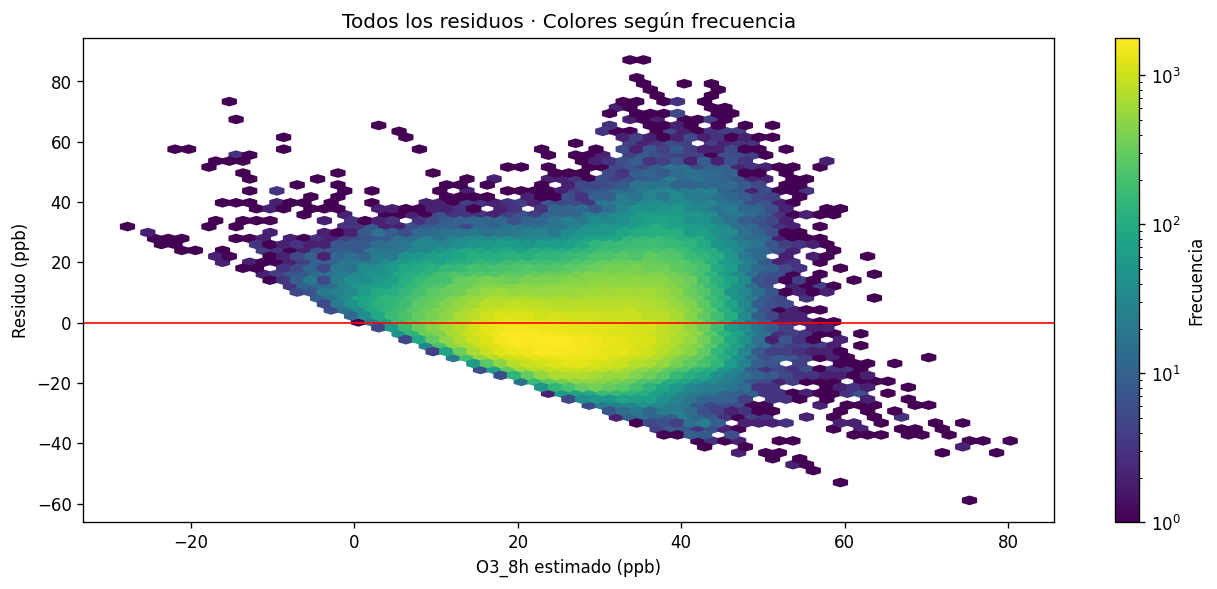

In [ ]:
res=train[['Estacion','Date']].copy()
res['observado']=y;res['estimado']=ols_est.fittedvalues.to_numpy()
res['residuo']=res.observado-res.estimado
diagnostico=[]
for est,g in res.groupby('Estacion'):
    e=g.set_index('Date').residuo.reindex(fechas[fechas<CORTE])
    diagnostico.append({'Estacion':est,'n':e.count(),'sesgo':e.mean(),
        'MAE':e.abs().mean(),'RMSE':np.sqrt(e.pow(2).mean()),
        'p95_abs':e.abs().quantile(.95),'r_residuo_1h':e.corr(e.shift(1)),
        'r_residuo_24h':e.corr(e.shift(24)),
        'pct_abs_mayor10':100*(e.abs()>10).sum()/e.count()})
diagnostico=pd.DataFrame(diagnostico)
display(diagnostico.round(3))
diagnostico.to_csv(SALIDA/'09_diagnostico_residuos.csv',index=False)
sens=[]
for L in [24,48,168]:
    tab=ic_est if L==24 else tabla_ic(ols_est,cov_calendario(ols_est,train,L,True))
    sens.append(tab.loc[XCOLS].assign(ventana_h=L).rename_axis('variable').reset_index())
sens=pd.concat(sens,ignore_index=True)
sens.to_csv(SALIDA/'10_sensibilidad_HAC.csv',index=False)
display(sens.query("variable=='NOX_lag1'").round(5))
fig,ax=plt.subplots()
hb=ax.hexbin(res.estimado,res.residuo,gridsize=65,mincnt=1,bins='log',cmap='viridis')
ax.axhline(0,color='red',lw=1);ax.set(xlabel='O3_8h estimado (ppb)',ylabel='Residuo (ppb)',
    title='Todos los residuos · Colores según frecuencia')
fig.colorbar(hb,ax=ax,label='Frecuencia');fig.tight_layout()
fig.savefig(SALIDA/'residuos.png',dpi=150);plt.show()

## 10. Validación temporal: entrenamiento 2020–2024, prueba 2025

El test no se usa para ajustar coeficientes. Se reportan RMSE, MAE, R² y N, tanto globales
como por estación. El RMSE global pondera estaciones por su número de observaciones;
la tabla por estación permite detectar cuándo ese promedio esconde problemas locales.

El RMSE 12.1390 ppb de la entrega es de ajuste dentro de muestra y procede de otro
procesamiento. No es una comparación equivalente con un RMSE de prueba nuevo.
Que test y train sean parecidos no basta para afirmar buena generalización: revisa
cobertura, utilidad del error y comparación con una referencia en las mismas filas.

In [ ]:
def metricas(y,p):
    y=np.asarray(y);p=np.asarray(p);err=y-p
    sst=np.sum((y-y.mean())**2)
    return {'n':len(y),'RMSE':np.sqrt(np.mean(err**2)),'MAE':np.mean(abs(err)),
            'R2':1-np.sum(err**2)/sst if sst>0 else np.nan}

evaluaciones=[];predicciones=[]
for nombre,ajuste,con_est in [('OLS_7',ols_base,False),('OLS_estacion',ols_est,True)]:
    for periodo,d in [('train',train),('test',test)]:
        pred=ajuste.predict(matriz(d,con_est)).to_numpy()
        evaluaciones.append(dict(modelo=nombre,periodo=periodo,**metricas(d.O3_8h,pred)))
        if periodo=='test' and con_est:
            predicciones=d[['Estacion','Date','O3_8h']].copy()
            predicciones['prediccion']=pred
evaluacion=pd.DataFrame(evaluaciones)
display(evaluacion.round(4))
evaluacion.to_csv(SALIDA/'11_validacion_temporal.csv',index=False)
por_est=[]
for est,g in predicciones.groupby('Estacion'):
    por_est.append(dict(Estacion=est,**metricas(g.O3_8h,g.prediccion)))
por_est=pd.DataFrame(por_est)
display(por_est.round(3))
print('RMSE macro (promedio de los RMSE por estación):',por_est.RMSE.mean())
por_est.to_csv(SALIDA/'12_validacion_por_estacion.csv',index=False)
predicciones.to_parquet(SALIDA/'predicciones_2025_OLS.parquet',index=False)

,modelo,periodo,n,RMSE,MAE,R2
0,OLS_7,train,326170,11.8460,9.2394,0.3689
1,OLS_7,test,63907,13.5101,10.2282,0.3577
2,OLS_estacion,train,326170,11.6361,9.1049,0.3911
3,OLS_estacion,test,63907,13.2322,10.0261,0.3838


,Estacion,n,RMSE,MAE,R2
0,CE,6952,13.605,10.437,0.410
1,NE,552,10.690,8.145,0.441
2,NE2,301,13.550,8.615,-0.494
3,NO2,4125,16.917,13.031,0.179
4,NTE,5636,12.868,10.123,0.388
5,NTE2,7545,11.354,8.903,0.499
6,SE,7143,12.413,9.460,0.410
7,SE2,7344,11.069,8.544,0.403
8,SE3,6522,12.108,9.162,0.303
9,SO,5448,14.921,11.454,0.361


RMSE macro (promedio de los RMSE por estación): 13.157551474083292


## 11. Contraste espacial solicitado: NE + NE2, SUR y SO

Usamos exactamente el contraste de la captura. Son **agrupaciones operativas**, no una
delimitación hidrológica demostrada. Las demás estaciones quedan en el modelo general.
Primero comparamos el coeficiente NOX con el mismo rezago de una hora.

Para seleccionar un rezago de NOX entre 1 y 24 horas, ajustamos con 2020–2023 y elegimos
por RMSE en 2024. Todos los candidatos usan las mismas filas dentro de cada grupo.
Los demás predictores mantienen su definición. El rezago elegido es el mejor entre los
candidatos examinados, no un tiempo causal de transporte. Este procedimiento tampoco
demuestra que el lag 17 de radiación sea óptimo.

In [ ]:
GRUPOS={'Noreste_NE_NE2':['NE','NE2'],'SUR':['SUR'],'SO':['SO']}
estratos=[];busqueda=[];elegidos=[]
for nombre,ests in GRUPOS.items():
    d=train.loc[train.Estacion.isin(ests)].reset_index(drop=True)
    x=matriz(d,False);fit=sm.OLS(d.O3_8h.to_numpy(),x).fit()
    tab=tabla_ic(fit,cov_calendario(fit,d,24,True))
    estratos.append(dict(grupo=nombre,n=len(d),**tab.loc['NOX_lag1'].to_dict()))
    # Grilla horaria, antes de eliminar filas.
    a=features.loc[features.Estacion.isin(ests)].copy()
    for lag in range(1,25):
        a[f'nox_{lag}']=a.groupby('Estacion').NOX.shift(lag)
    fijos=[c for c in XCOLS if c!='NOX_lag1']
    comunes=a.dropna(subset=['O3_8h']+fijos+[f'nox_{l}' for l in range(1,25)])
    tr=comunes.loc[comunes.Date<'2024-01-01'].reset_index(drop=True)
    va=comunes.loc[(comunes.Date>='2024-01-01')&(comunes.Date<CORTE)].reset_index(drop=True)
    if len(tr)<100 or len(va)<100:
        print('No hay soporte suficiente para elegir lag:',nombre);continue
    for lag in range(1,25):
        cols=fijos+[f'nox_{lag}']
        fit_l=sm.OLS(tr.O3_8h.to_numpy(),matriz(tr,False,cols)).fit()
        rmse=metricas(va.O3_8h,fit_l.predict(matriz(va,False,cols)))['RMSE']
        busqueda.append(dict(grupo=nombre,lag=lag,RMSE_val_2024=rmse,n_train=len(tr),n_val=len(va)))
    mejor=min([r for r in busqueda if r['grupo']==nombre],key=lambda r:r['RMSE_val_2024'])
    cols=fijos+[f"nox_{mejor['lag']}"]
    ajuste_d=a.loc[a.Date<CORTE].dropna(subset=['O3_8h']+cols).reset_index(drop=True)
    fit_l=sm.OLS(ajuste_d.O3_8h.to_numpy(),matriz(ajuste_d,False,cols)).fit()
    t=tabla_ic(fit_l,cov_calendario(fit_l,ajuste_d,24,True)).loc[cols[-1]]
    prueba=a.loc[a.Date>=CORTE].dropna(subset=['O3_8h']+cols).reset_index(drop=True)
    pred=fit_l.predict(matriz(prueba,False,cols))
    elegidos.append(dict(grupo=nombre,lag_elegido=mejor['lag'],n_train=len(ajuste_d),
        RMSE_val_2024=mejor['RMSE_val_2024'],beta_NOX=t.beta,
        IC95_inf_condicional=t.IC95_inf,IC95_sup_condicional=t.IC95_sup,
        **{'test_'+k:v for k,v in metricas(prueba.O3_8h,pred).items()}))
estratos=pd.DataFrame(estratos);busqueda=pd.DataFrame(busqueda);elegidos=pd.DataFrame(elegidos)
display(estratos.round(5));display(elegidos.round(4))
estratos.to_csv(SALIDA/'13_NOX_mismo_lag_por_grupo.csv',index=False)
busqueda.to_csv(SALIDA/'14_busqueda_lag_NOX.csv',index=False)
elegidos.to_csv(SALIDA/'15_lag_elegido_por_grupo.csv',index=False)

,grupo,n,beta,SE_OLS,SE_robusto,IC95_inf,IC95_sup,p_asintotico,factor_SE
0,Noreste_NE_NE2,48701,-0.10363,0.00195,0.00796,-0.11923,-0.08802,0.0,4.07244
1,SUR,24533,-0.15381,0.00389,0.00875,-0.17096,-0.13665,0.0,2.24841
2,SO,29416,-0.07776,0.00244,0.00429,-0.08617,-0.06936,0.0,1.75593


,grupo,lag_elegido,n_train,RMSE_val_2024,beta_NOX,IC95_inf_condicional,IC95_sup_condicional,test_n,test_RMSE,test_MAE,test_R2
0,Noreste_NE_NE2,3,48689,11.9281,-0.1385,-0.1595,-0.1175,854,12.4418,8.7387,0.2756
1,SUR,2,24608,13.2460,-0.1658,-0.1827,-0.1489,5793,13.0057,9.2785,0.4068
2,SO,3,29388,14.0407,-0.1037,-0.1117,-0.0957,5450,14.7799,11.1899,0.3710


**Interpretación del contraste:** no basta que un grupo resulte significativo y otro no
para concluir que sus coeficientes difieren. A continuación probamos directamente
las diferencias de pendientes NOX mediante interacciones y HAC espacial-temporal.
Los IC del lag elegido arriba son condicionales al modelo seleccionado: no incorporan
la incertidumbre de la selección de rezagos. El contraste formal siguiente mantiene
el lag 1 predefinido y evita ese problema de selección para esta comparación concreta.

In [ ]:
mapa_grupo={e:g for g,es in GRUPOS.items() for e in es}
dd=train.loc[train.Estacion.isin(mapa_grupo)].copy().reset_index(drop=True)
dd['grupo']=dd.Estacion.map(mapa_grupo)
xx=matriz(dd,False)
# Pendientes de todos los predictores por grupo: referencia Noreste.
for grupo in ['SUR','SO']:
    flag=dd.grupo.eq(grupo).astype(float)
    xx[f'intercepto_{grupo}']=flag
    for c in XCOLS: xx[f'{c}:{grupo}']=dd[c].to_numpy()*flag
fit_int=sm.OLS(dd.O3_8h.to_numpy(),xx).fit()
cov_int=cov_calendario(fit_int,dd,24,True)
ic_int=tabla_ic(fit_int,cov_int)
contrastes=ic_int.loc[['NOX_lag1:SUR','NOX_lag1:SO']].copy()
display(contrastes.round(5))
contrastes.to_csv(SALIDA/'16_diferencias_NOX_vs_noreste.csv')

,beta,SE_OLS,SE_robusto,IC95_inf,IC95_sup,p_asintotico,factor_SE
NOX_lag1:SUR,-0.05018,0.00453,0.01114,-0.07201,-0.02835,0.00001,2.45965
NOX_lag1:SO,0.02586,0.00302,0.00832,0.00955,0.04217,0.00188,2.75671


## 12. Sensibilidad: selección de estaciones

La exclusión de NO responde a cobertura, no a que su comportamiento contradiga el modelo.
La tabla de selección y los diagnósticos quedan guardados. Las doce estaciones no tienen
cobertura uniforme: reporta la restricción, los años y las ocho variables que definieron
la decisión. NE3 tiene cero cobertura conjunta en entrenamiento, por lo que incluirla
con un intercepto propio en un modelo entrenado hasta 2024 no permite estimar ese efecto.

## 13. Guardar panel y datos listos para el equipo

`panel_12_horario.parquet` conserva todas las variables disponibles y los huecos.
`features_12_horario.parquet` conserva también ventanas y rezagos con sus huecos.
`modelo_12_completo.parquet` contiene solamente las filas necesarias para la regresión.
El filtrado final depende del modelo; no aplicamos `dropna()` indiscriminadamente sobre
todos los contaminantes del proyecto.

In [ ]:
p12.reset_index().to_parquet(SALIDA/'panel_12_horario.parquet',index=False)
features.to_parquet(SALIDA/'features_12_horario.parquet',index=False)
modelo_df.to_parquet(SALIDA/'modelo_12_completo.parquet',index=False)
config={'periodo':[str(INICIO),str(FIN)],'corte_test':str(CORTE),
    'seleccion':'12 mayores coberturas conjuntas CORE en 2020-2024',
    'core':CORE,'excluidas':QUITAR,'conservadas':USAR,
    'predictores':XCOLS,'HAC_horas':24,
    'N_train':len(train),'N_test':len(test),
    'modelo_OLS':'Estimación contemporánea de O3_8h; viento de la hora actual'}
(SALIDA/'configuracion.json').write_text(json.dumps(config,indent=2,ensure_ascii=False))
print('Archivos guardados en:',SALIDA)

Archivos guardados en: carpeta resultados de la ejecución local


## 14. Excedencias por estación y temporada: producto descriptivo

Se calculan con **O3 de las 15 estaciones**, no con la intersección de los predictores:
una estación descartada para regresión todavía puede aportar ozono válido.

La captura pide 0.051 ppm = **51 ppb**. Según la tabla oficial de INECC/SINAICA ese umbral
corresponde a partir de 2026; 2022–2023 usan 65 ppb y 2024–2025, 60 ppb. Aplicar 51 ppb a
2020–2025 es un **escenario retrospectivo uniforme**, no una clasificación legal de esos años.
Se entrega ese escenario y otro con 65/60 ppb para 2022–2025; 2020–2021 quedan sin
clasificación histórica en este segundo escenario.

Contamos ventanas de ocho horas superiores al umbral y días con alguna ventana superior.
También informamos cuántos días tienen al menos 18 ventanas disponibles y los máximos
diarios correspondientes. Las ventanas se asignan por su hora de cierre. Los días se
cuentan por separado de las ventanas solapadas; no llamamos a cada ventana un episodio.

Esto **no es una certificación de cumplimiento de la NOM**: el cálculo usa series ya
limpiadas por el equipo, reglas explícitas de cobertura y no implementa todo el protocolo
regulatorio de validación, redondeo, asignación y suficiencia anual. Las temporadas aquí
son meteorológicas (DJF, MAM, JJA, SON), no estaciones seca/húmeda definidas para Monterrey.
Se etiquetan por año calendario y temporada, sin unir inviernos de dos años diferentes.
Fuente: https://sinaica.inecc.gob.mx/pags/noms.php

In [ ]:
oz=[]
for est,g in panel[['O3']].groupby(level='Estacion'):
    h=g.droplevel('Estacion')
    m=h.O3.rolling(8,min_periods=6).mean()
    oz.append(pd.DataFrame({'Estacion':est,'Date':h.index,'O3_8h':m.to_numpy()}))
oz=pd.concat(oz,ignore_index=True)
oz['dia']=oz.Date.dt.floor('D');oz['year']=oz.Date.dt.year
temporadas={12:'Invierno_DJF',1:'Invierno_DJF',2:'Invierno_DJF',
            3:'Primavera_MAM',4:'Primavera_MAM',5:'Primavera_MAM',
            6:'Verano_JJA',7:'Verano_JJA',8:'Verano_JJA',
            9:'Otono_SON',10:'Otono_SON',11:'Otono_SON'}
oz['temporada']=oz.Date.dt.month.map(temporadas)
resultados_exc=[]
for escenario in ['51ppb_retrospectivo','umbrales_2022_2025']:
    z=oz.copy()
    z['umbral_ppb']=51. if escenario=='51ppb_retrospectivo' else z.year.map({2022:65.,2023:65.,2024:60.,2025:60.})
    z['valida']=z.O3_8h.notna() & z.umbral_ppb.notna()
    z['excede']=(z.O3_8h>z.umbral_ppb)&z.valida
    diario=z.groupby(['Estacion','year','temporada','dia']).agg(
        ventanas_validas=('valida','sum'),ventanas_excedidas=('excede','sum'),
        alguna_excedencia=('excede','any'))
    diario['dia_18ventanas']=diario.ventanas_validas>=18
    diario['dia_excede_18ventanas']=diario.alguna_excedencia & diario.dia_18ventanas
    t=diario.groupby(['Estacion','year','temporada']).agg(
        dias_calendario=('ventanas_validas','size'),ventanas_validas=('ventanas_validas','sum'),
        ventanas_excedidas=('ventanas_excedidas','sum'),
        dias_con_alguna_excedencia=('alguna_excedencia','sum'),
        dias_con_18ventanas=('dia_18ventanas','sum'),
        dias_excedidos_con_18ventanas=('dia_excede_18ventanas','sum')).reset_index()
    t['pct_ventanas_excedidas']=100*t.ventanas_excedidas/t.ventanas_validas.replace(0,np.nan)
    t['cobertura_ventanas_pct']=100*t.ventanas_validas/(24*t.dias_calendario)
    t['escenario']=escenario
    no_eval=t.ventanas_validas.eq(0)
    t.loc[no_eval,['ventanas_excedidas','dias_con_alguna_excedencia','dias_excedidos_con_18ventanas']]=np.nan
    resultados_exc.append(t)
excedencias=pd.concat(resultados_exc,ignore_index=True)
display(excedencias.query("year==2025 and escenario=='51ppb_retrospectivo'").head(12).round(2))
excedencias.to_csv(SALIDA/'17_excedencias_estacion_temporada.csv',index=False)

,Estacion,year,temporada,dias_calendario,ventanas_validas,ventanas_excedidas,dias_con_alguna_excedencia,dias_con_18ventanas,dias_excedidos_con_18ventanas,pct_ventanas_excedidas,cobertura_ventanas_pct,escenario
20,CE,2025,Invierno_DJF,90,1948,119.0,24.0,72,22.0,6.11,90.19,51ppb_retrospectivo
21,CE,2025,Otono_SON,91,2139,378.0,52.0,88,50.0,17.67,97.94,51ppb_retrospectivo
22,CE,2025,Primavera_MAM,92,2163,476.0,65.0,90,65.0,22.01,97.96,51ppb_retrospectivo
23,CE,2025,Verano_JJA,92,2163,269.0,48.0,90,47.0,12.44,97.96,51ppb_retrospectivo
44,NE,2025,Invierno_DJF,90,2025,75.0,17.0,79,14.0,3.70,93.75,51ppb_retrospectivo
45,NE,2025,Otono_SON,91,2083,227.0,39.0,84,37.0,10.90,95.38,51ppb_retrospectivo
46,NE,2025,Primavera_MAM,92,2125,351.0,54.0,86,52.0,16.52,96.24,51ppb_retrospectivo
47,NE,2025,Verano_JJA,92,1562,108.0,24.0,63,23.0,6.91,70.74,51ppb_retrospectivo
68,NE2,2025,Invierno_DJF,90,1960,17.0,5.0,75,4.0,0.87,90.74,51ppb_retrospectivo
69,NE2,2025,Otono_SON,91,2160,80.0,17.0,88,15.0,3.70,98.90,51ppb_retrospectivo


## 15. LSTM-NARX: pronóstico de O3_8h una hora adelante

**Activa `EJECUTAR_LSTM=True` para entrenar.** Esta parte es más lenta y no es necesaria
para obtener selección de estaciones, dispersión, HAC o el modelo lineal anterior.

La red recibe las últimas 24 horas de la propia respuesta y de siete variables exógenas,
hasta t−1, y predice O3_8h(t). Es una LSTM autorregresiva con entradas exógenas
(NARX en sentido funcional), no una predicción recursiva de múltiples pasos.
La evaluación es de un paso con historia observada: al avanzar por 2025 puede usar
mediciones de horas anteriores de 2025. No ve ninguna medición de la hora objetivo.

Se descartan secuencias incompletas y nunca se cruzan estaciones. La estandarización
usa sólo entrenamiento. Seleccionamos el número de épocas con 2020–2023/2024,
reinicializamos, reestandarizamos y ajustamos 2020–2024 antes de abrir test 2025.
La selección previa de estaciones ya inspeccionó cobertura de 2024: se declara esa
decisión de diseño; el test 2025 queda reservado para evaluar predicción.

Se compara con persistencia y una regresión ARX con las mismas 24 horas y estaciones,
en exactamente las mismas filas de test. La red no garantiza mejorar por ser no lineal,
ni elimina por sí misma heterocedasticidad o incertidumbre. Un RMSE bajo de O3_8h puede
reflejar el solapamiento de siete horas entre ventanas consecutivas; por eso es esencial
compararla con persistencia. No prometemos superar 12.1390 antes de ejecutarla.

In [ ]:
EJECUTAR_LSTM = False
EPOCAS_MAX = 12
PACIENCIA = 3
VENTANA = 24
LOTE = 512
SEMILLA = 2026

if EJECUTAR_LSTM:
    import importlib.util, subprocess, sys
    if importlib.util.find_spec('torch') is None:
        subprocess.check_call([sys.executable,'-m','pip','install','-q','torch'])
    import torch
    from torch import nn
    from torch.utils.data import Dataset, DataLoader
    torch.manual_seed(SEMILLA); np.random.seed(SEMILLA)
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Dispositivo:',device)

    entradas=['O3_8h','PM2.5','PM10','NOX','SR','TOUT','U_Wind','V_Wind']
    raw=[]; targets=[]; tiempo=[]; sid=[]; indices=[]
    offset=0
    for j,est in enumerate(USAR):
        h=features.loc[features.Estacion.eq(est)].sort_values('Date')
        a=h[entradas].to_numpy(np.float32)
        y0=h.O3_8h.to_numpy(np.float32)
        completa=np.isfinite(a).all(axis=1)
        # En la fila t exige entradas válidas de t-24 a t-1.
        ok=pd.Series(completa.astype(int)).rolling(VENTANA).sum().shift(1).eq(VENTANA).to_numpy()
        ids=np.flatnonzero(ok & np.isfinite(y0))
        indices.extend((ids+offset).tolist())
        raw.append(a);targets.append(y0);tiempo.append(h.Date.to_numpy())
        sid.append(np.full(len(h),j));offset+=len(h)
    raw=np.concatenate(raw); yy=np.concatenate(targets)
    tiempos=np.concatenate(tiempo); estaciones_id=np.concatenate(sid)
    indices=np.array(indices)
    i_train=indices[tiempos[indices]<np.datetime64('2024-01-01')]
    i_val=indices[(tiempos[indices]>=np.datetime64('2024-01-01'))&(tiempos[indices]<np.datetime64('2025-01-01'))]
    i_final=indices[tiempos[indices]<np.datetime64('2025-01-01')]
    i_test=indices[tiempos[indices]>=np.datetime64('2025-01-01')]
    if min(map(len,[i_train,i_val,i_test]))<100:
        raise ValueError('Pocas secuencias para entrenamiento/validación/prueba')

    def escalar(corte,ids_y):
        pasado=raw[tiempos<np.datetime64(corte)]
        media=np.nanmean(pasado,axis=0);sd=np.nanstd(pasado,axis=0)
        sd=np.where(sd>1e-8,sd,1.)
        ym=float(yy[ids_y].mean());ys=max(float(yy[ids_y].std()),1e-8)
        return ((raw-media)/sd).astype(np.float32),ym,ys,media,sd

    class Secuencias(Dataset):
        def __init__(self,a,ids,ym,ys):self.a=a;self.ids=ids;self.ym=ym;self.ys=ys
        def __len__(self):return len(self.ids)
        def __getitem__(self,k):
            t=self.ids[k]
            return (torch.from_numpy(self.a[t-VENTANA:t]),
                    torch.tensor(estaciones_id[t],dtype=torch.long),
                    torch.tensor((yy[t]-self.ym)/self.ys,dtype=torch.float32))

    class NARX(nn.Module):
        def __init__(self):
            super().__init__()
            self.lstm=nn.LSTM(len(entradas),32,batch_first=True)
            self.emb=nn.Embedding(len(USAR),4)
            self.head=nn.Sequential(nn.Linear(36,16),nn.ReLU(),nn.Linear(16,1))
        def forward(self,x,est):
            h,_=self.lstm(x)
            return self.head(torch.cat([h[:,-1,:],self.emb(est)],dim=1)).squeeze(1)

    def loader(a,ids,ym,ys,shuffle=False):
        return DataLoader(Secuencias(a,ids,ym,ys),batch_size=LOTE,shuffle=shuffle,num_workers=0)
    def entrenar_epoca(net,dl,opt):
        net.train();s=0.;n=0
        for xx,ee,zz in dl:
            xx,ee,zz=xx.to(device),ee.to(device),zz.to(device)
            opt.zero_grad();loss=((net(xx,ee)-zz)**2).mean();loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(),1.);opt.step()
            s+=loss.item()*len(zz);n+=len(zz)
        return (s/n)**.5
    def predecir(net,dl,ym,ys):
        net.eval();p=[]
        with torch.no_grad():
            for xx,ee,_ in dl:p.append(net(xx.to(device),ee.to(device)).cpu().numpy()*ys+ym)
        return np.concatenate(p)

    a,ym,ys,media,sd=escalar('2024-01-01',i_train)
    net=NARX().to(device);opt=torch.optim.Adam(net.parameters(),lr=.001)
    tr_dl=loader(a,i_train,ym,ys,True);va_dl=loader(a,i_val,ym,ys)
    mejor=np.inf;epoca_mejor=1;sin_mejora=0;hist=[]
    for ep in range(1,EPOCAS_MAX+1):
        tr_rmse=entrenar_epoca(net,tr_dl,opt)*ys
        va_rmse=metricas(yy[i_val],predecir(net,va_dl,ym,ys))['RMSE']
        hist.append({'epoca':ep,'RMSE_train':tr_rmse,'RMSE_val':va_rmse})
        print(ep,'train',round(tr_rmse,3),'val',round(va_rmse,3))
        if va_rmse<mejor:
            mejor=va_rmse;epoca_mejor=ep;sin_mejora=0
        else:sin_mejora+=1
        if sin_mejora>=PACIENCIA:break
    pd.DataFrame(hist).to_csv(SALIDA/'18_historia_LSTM.csv',index=False)

    # Reentrenamiento desde cero en 2020-2024, número de épocas ya fijado.
    a,ym,ys,media,sd=escalar('2025-01-01',i_final)
    torch.manual_seed(SEMILLA)
    net=NARX().to(device);opt=torch.optim.Adam(net.parameters(),lr=.001)
    for ep in range(epoca_mejor):
        print('Refit',ep+1,entrenar_epoca(net,loader(a,i_final,ym,ys,True),opt)*ys)
    pred_lstm=predecir(net,loader(a,i_test,ym,ys),ym,ys)
    pred_persistencia=yy[i_test-1]

    # ARX lineal: mismo historial completo de 24h, entrenamiento por lotes QR.
    # QR incremental evita materializar una matriz gigante o invertir X'X.
    def x_arx(ids):
        x=np.stack([a[t-VENTANA:t].ravel() for t in ids]).astype(float)
        dummies=np.eye(len(USAR))[estaciones_id[ids],1:]
        return np.column_stack([np.ones(len(ids)),x,dummies])
    R=None;qy=None
    for start in range(0,len(i_final),2048):
        ids=i_final[start:start+2048]; xb=x_arx(ids);yb=yy[ids].astype(float)
        if R is not None: xb=np.vstack([R,xb]);yb=np.r_[qy,yb]
        q,R=np.linalg.qr(xb,mode='reduced');qy=q.T@yb
    beta_arx=np.linalg.lstsq(R,qy,rcond=None)[0]
    pred_arx=np.concatenate([x_arx(i_test[i:i+2048])@beta_arx for i in range(0,len(i_test),2048)])
    tabla_lstm=pd.DataFrame([dict(modelo=n,**metricas(yy[i_test],p)) for n,p in
        [('Persistencia',pred_persistencia),('ARX_24h',pred_arx),('LSTM_NARX',pred_lstm)]])
    display(tabla_lstm.round(4))
    tabla_lstm.to_csv(SALIDA/'19_test_comun_LSTM_ARX_persistencia.csv',index=False)
    pred_df=pd.DataFrame({'Date':tiempos[i_test],
        'Estacion':np.array(USAR)[estaciones_id[i_test]],'observado':yy[i_test],
        'LSTM':pred_lstm,'ARX':pred_arx,'persistencia':pred_persistencia})
    pred_df.to_parquet(SALIDA/'predicciones_2025_LSTM.parquet',index=False)
    tabla_lstm_est=[]
    for est,g in pred_df.groupby('Estacion'):
        for col in ['LSTM','ARX','persistencia']:
            tabla_lstm_est.append(dict(Estacion=est,modelo=col,**metricas(g.observado,g[col])))
    pd.DataFrame(tabla_lstm_est).to_csv(SALIDA/'20_LSTM_por_estacion.csv',index=False)
    torch.save({'state_dict':net.state_dict(),'entradas':entradas,'estaciones':USAR,
        'ventana':VENTANA,'media':media.tolist(),'sd':sd.tolist(),'y_media':ym,'y_sd':ys,
        'epocas':epoca_mejor,'semilla':SEMILLA},SALIDA/'LSTM_NARX.pt')
else:
    print('LSTM preparada. Cambia EJECUTAR_LSTM a True para entrenar y comparar.')

LSTM preparada. Cambia EJECUTAR_LSTM a True para entrenar y comparar.


## 16. Descargar tu aporte

El ZIP reúne paneles, tablas y figuras. No necesitas modificar ni ejecutar el repositorio.
Para reportar el trabajo distingue **resultados ejecutados** de código preparado: la LSTM
sólo queda completada cuando la actives, termine y se genere la tabla de test común.

Para tu explicación al equipo utiliza: estaciones excluidas y criterio, cobertura por
año, distancias individuales al promedio, IC de los siete coeficientes, sensibilidad
HAC, resultados por grupo y RMSE 2025. No sustituyas las cifras del reporte anterior sin
explicar que esta versión corrige el calendario y modifica la muestra.

In [ ]:
zip_path=shutil.make_archive(str(BASE/'aporte_Mikey_resultados'),'zip',SALIDA)
print('ZIP creado:',zip_path)
from google.colab import files
files.download(zip_path)

## Fuentes y alcance de verificación

Datos y definiciones: archivos `*_clean.parquet`, `Etiquetas.xlsx`, `Entrega3_Eq1.pdf`
(secciones 2, 4 y 7), `3_features.ipynb`, notebooks ARX y `script_final_tareas.py`
adjuntos en esta conversación. La configuración propuesta no valida de nuevo las
banderas originales de todos los Excel.

Documentación técnica consultada el 11 de septiembre de 2026:

- [Statsmodels: Newey–West para una serie](https://www.statsmodels.org/stable/generated/statsmodels.stats.sandwich_covariance.cov_hac.html).
- [Statsmodels: HAC de panel](https://www.statsmodels.org/stable/generated/statsmodels.stats.sandwich_covariance.cov_nw_panel.html).
- [Statsmodels: Driscoll–Kraay](https://www.statsmodels.org/stable/generated/statsmodels.stats.sandwich_covariance.cov_nw_groupsum.html).
- [PyTorch: LSTM](https://docs.pytorch.org/docs/2.14/generated/torch.nn.LSTM.html).
- [INECC/SINAICA: tabla de umbrales por periodo](https://sinaica.inecc.gob.mx/pags/noms.php).

Los bloques principales se verifican con los adjuntos en un entorno Python local.
La autorización interactiva de Drive y la descarga se realizan en tu Colab. La LSTM
se entrega como código preparado, sin afirmar entrenamiento en GPU ni un RMSE obtenido.